# Qwen2-VL-2B Vision Encoder LoRA Fine-Tuning

**Goal:** Fix the 92% perception failure bottleneck by applying LoRA to the last 2 vision encoder blocks.

**Hardware:** Colab Pro A100 (80GB) | **Dataset:** 400 gauge images, 800 constraint-paired rows

**Strategy:** QLoRA 4-bit base → LoRA on `visual.blocks.{22,23}` → Save adapter → Deploy at 8GB edge

## Cell 0: Setup & Dependencies

In [3]:
!pip install -q "transformers>=4.45.0" "peft>=0.13.0" "trl>=0.12.0" "bitsandbytes>=0.44.0" "accelerate>=0.34.0" qwen-vl-utils datasets pillow tensorboard

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}, Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "No GPU")


PyTorch: 2.10.0+cu128
CUDA: True, Device: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


## Cell 1: Mount Google Drive & Load Data

In [7]:
from google.colab import drive
import json, os, shutil

drive.mount('/content/drive')

DRIVE_DATA = "/content/drive/MyDrive/Dataset_FineTune"
DRIVE_OUTPUT = "/content/drive/MyDrive/Dataset_FineTune/lora_adapter"
LOCAL_DATA = "/content/finetune_data"

if not os.path.exists(LOCAL_DATA):
    print("Copying data from Drive to local...")
    shutil.copytree(DRIVE_DATA, LOCAL_DATA)
    print("Done!")

with open(os.path.join(LOCAL_DATA, "finetune_metadata_augmented.json"), 'r') as f:
    metadata = json.load(f)

print(f"Loaded {len(metadata)} training rows")
print(f"Unique images: {len(set(r['image_id'] for r in metadata))}")

sample = metadata[0]
sample_path = os.path.join(LOCAL_DATA, sample["full_path"].replace("Dataset_FineTune/", ""))
print(f"Sample image exists: {os.path.exists(sample_path)} → {sample_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying data from Drive to local...
Done!
Loaded 800 training rows
Unique images: 400
Sample image exists: True → /content/finetune_data/Selected images/ft_gauge (1).jpg


## Cell 2: Load Qwen2-VL-2B with 4-bit Quantization

In [9]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading model (4-bit)...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


Loading model (4-bit)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded. Parameters: 1222.3M


## Cell 3: Inspect Vision Encoder Architecture

In [10]:
# Print vision encoder structure to identify exact layer names for LoRA targeting
print("=== Vision Encoder Blocks ===")
for name, module in model.named_modules():
    if "visual" in name and ("attn" in name or "mlp" in name):
        if hasattr(module, 'weight') or any(hasattr(module, a) for a in ['in_features', 'out_features']):
            print(f"  {name}: {type(module).__name__}")

print("\n=== Last 3 Visual Blocks (LoRA targets) ===")
for name, param in model.named_parameters():
    if "visual" in name and any(f"blocks.{i}" in name for i in [21, 22, 23]):
        print(f"  {name}: {param.shape}")

=== Vision Encoder Blocks ===
  model.visual.blocks.0.attn.qkv: Linear4bit
  model.visual.blocks.0.attn.proj: Linear4bit
  model.visual.blocks.0.mlp.fc1: Linear4bit
  model.visual.blocks.0.mlp.fc2: Linear4bit
  model.visual.blocks.1.attn.qkv: Linear4bit
  model.visual.blocks.1.attn.proj: Linear4bit
  model.visual.blocks.1.mlp.fc1: Linear4bit
  model.visual.blocks.1.mlp.fc2: Linear4bit
  model.visual.blocks.2.attn.qkv: Linear4bit
  model.visual.blocks.2.attn.proj: Linear4bit
  model.visual.blocks.2.mlp.fc1: Linear4bit
  model.visual.blocks.2.mlp.fc2: Linear4bit
  model.visual.blocks.3.attn.qkv: Linear4bit
  model.visual.blocks.3.attn.proj: Linear4bit
  model.visual.blocks.3.mlp.fc1: Linear4bit
  model.visual.blocks.3.mlp.fc2: Linear4bit
  model.visual.blocks.4.attn.qkv: Linear4bit
  model.visual.blocks.4.attn.proj: Linear4bit
  model.visual.blocks.4.mlp.fc1: Linear4bit
  model.visual.blocks.4.mlp.fc2: Linear4bit
  model.visual.blocks.5.attn.qkv: Linear4bit
  model.visual.blocks.5.attn.p

## Cell 4: LoRA Configuration

Target: Last 2 vision encoder transformer blocks (blocks 22-23 of 24).
The exact module names will be confirmed from Cell 3 output.

In [11]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

for param in model.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "model.visual.blocks.22.attn.qkv",
        "model.visual.blocks.22.attn.proj",
        "model.visual.blocks.22.mlp.fc1",
        "model.visual.blocks.22.mlp.fc2",
        "model.visual.blocks.23.attn.qkv",
        "model.visual.blocks.23.attn.proj",
        "model.visual.blocks.23.mlp.fc1",
        "model.visual.blocks.23.mlp.fc2",
    ],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 655,360 || all params: 2,209,640,960 || trainable%: 0.0297


## Cell 5: Build Training Dataset

Convert metadata JSON → HuggingFace Dataset with Qwen2-VL chat format.

In [12]:
from datasets import Dataset
from PIL import Image

def resolve_image_path(row):
    """Resolve image path from metadata to local filesystem."""
    rel_path = row["full_path"].replace("Dataset_FineTune/", "")
    return os.path.join(LOCAL_DATA, rel_path)

def build_conversation(row):
    """Build a single training conversation from a metadata row."""
    img_path = resolve_image_path(row)
    
    # Build the prompt matching our evaluation protocol
    constraint = row["logic_constraint"]
    prompt = (
        f"You are an industrial safety auditor inspecting field equipment. "
        f"Examine this gauge image carefully. "
        f"Read the numeric value shown on the gauge. "
        f"Then apply this safety rule: {constraint} "
        f"Provide your reading and a verdict: [SAFE] or [UNSAFE]."
    )
    
    # Build the expected response
    value = row["ground_truth_value"]
    unit = row.get("unit") or "units"
    verdict = row["expected_verdict"]
    reasoning = row["reasoning"]
    
    if isinstance(value, float) and value == int(value):
        value = int(value)
    
    response = f"The gauge reads {value} {unit}. {reasoning} [{verdict}]"
    
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img_path},
                    {"type": "text", "text": prompt}
                ]
            },
            {
                "role": "assistant", 
                "content": [
                    {"type": "text", "text": response}
                ]
            }
        ]
    }

# Filter out rows where images don't exist
valid_rows = []
missing = 0
for row in metadata:
    path = resolve_image_path(row)
    if os.path.exists(path):
        valid_rows.append(row)
    else:
        missing += 1

if missing > 0:
    print(f"WARNING: {missing} images not found, skipped")

# Build conversations
conversations = [build_conversation(r) for r in valid_rows]

# Split 90/10
import random
random.seed(42)
random.shuffle(conversations)
split_idx = int(len(conversations) * 0.9)
train_convos = conversations[:split_idx]
val_convos = conversations[split_idx:]

train_dataset = Dataset.from_list(train_convos)
val_dataset = Dataset.from_list(val_convos)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"\nSample conversation:")
print(json.dumps(train_convos[0], indent=2, default=str)[:500])

Train: 720 | Val: 80

Sample conversation:
{
  "messages": [
    {
      "role": "user",
      "content": [
        {
          "type": "image",
          "image": "/content/finetune_data/Augmented/ft_gauge (89)_crop_bright.jpg"
        },
        {
          "type": "text",
          "text": "You are an industrial safety auditor inspecting field equipment. Examine this gauge image carefully. Read the numeric value shown on the gauge. Then apply this safety rule: Alert if > 6 NA. Provide your reading and a verdict: [SAFE] or [UNSAFE]."
 


## Cell 6: Training

In [18]:
from trl import SFTConfig, SFTTrainer
from PIL import Image

# Limit image token count by resizing
MAX_IMAGE_SIZE = 384

def collate_fn(examples):
    all_input_ids = []
    all_attention_mask = []
    all_labels = []
    all_pixel_values = []
    all_image_grid_thw = []
    
    for example in examples:
        messages = example["messages"]
        
        img_path = None
        prompt_text = ""
        for content in messages[0]["content"]:
            if content["type"] == "image":
                img_path = content["image"]
            elif content["type"] == "text":
                prompt_text = content["text"]
        
        response_text = messages[1]["content"][0]["text"]
        
        img = Image.open(img_path).convert("RGB")
        img.thumbnail((MAX_IMAGE_SIZE, MAX_IMAGE_SIZE))
        
        text = (
            "<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n"
            "<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>\n"
            f"{prompt_text}<|im_end|>\n"
            f"<|im_start|>assistant\n{response_text}<|im_end|>\n"
        )
        
        inputs = processor(
            text=[text],
            images=[img],
            return_tensors="pt",
            padding=False,
        )
        
        all_input_ids.append(inputs["input_ids"].squeeze(0))
        all_attention_mask.append(inputs["attention_mask"].squeeze(0))
        all_pixel_values.append(inputs["pixel_values"])
        all_image_grid_thw.append(inputs["image_grid_thw"])
        
        labels = inputs["input_ids"].squeeze(0).clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100
        all_labels.append(labels)
    
    max_len = max(ids.size(0) for ids in all_input_ids)
    pad_id = processor.tokenizer.pad_token_id
    
    padded_input_ids = []
    padded_attention = []
    padded_labels = []
    
    for ids, mask, lab in zip(all_input_ids, all_attention_mask, all_labels):
        pad_len = max_len - ids.size(0)
        padded_input_ids.append(torch.cat([ids, torch.full((pad_len,), pad_id, dtype=ids.dtype)]))
        padded_attention.append(torch.cat([mask, torch.zeros(pad_len, dtype=mask.dtype)]))
        padded_labels.append(torch.cat([lab, torch.full((pad_len,), -100, dtype=lab.dtype)]))
    
    batch = {
        "input_ids": torch.stack(padded_input_ids),
        "attention_mask": torch.stack(padded_attention),
        "labels": torch.stack(padded_labels),
        "pixel_values": torch.cat(all_pixel_values, dim=0),
        "image_grid_thw": torch.cat(all_image_grid_thw, dim=0),
    }
    return batch

training_args = SFTConfig(
    output_dir="/content/qwen2vl_lora_output",
    num_train_epochs=5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    bf16=True,
    gradient_checkpointing=True,
    logging_dir="/content/tb_logs",
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    remove_unused_columns=False,
    report_to="tensorboard",
    seed=42,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    processing_class=processor.tokenizer,
)

print(f"Training: {len(train_dataset)} samples, batch=2, accum=4, epochs=5")
print("Starting training...")
trainer.train()
print("Training complete!")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Tokenizing train dataset:   0%|          | 0/720 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/80 [00:00<?, ? examples/s]

Training: 720 samples, batch=2, accum=4, epochs=5
Starting training...


Step,Training Loss,Validation Loss
50,13.142970,13.296556
100,12.473007,12.190039
150,7.713236,7.309331
200,6.529540,6.462491
250,6.279301,6.237941
300,5.990091,5.912126
350,5.806914,5.788405
400,5.739622,5.762983
450,5.772861,5.762390


Training complete!


## Cell 7: Loss Curves

<IPython.core.display.Javascript object>

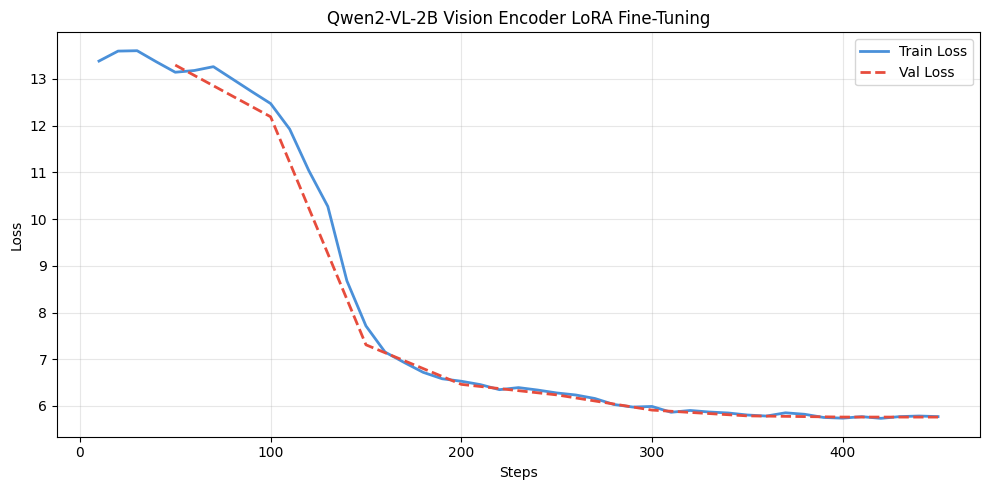

Final train loss: 5.7729
Final val loss: 5.7624


In [19]:
%load_ext tensorboard
%tensorboard --logdir /content/tb_logs

# Alternative: plot from trainer log history
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_losses = [(l["step"], l["loss"]) for l in log_history if "loss" in l]
eval_losses = [(l["step"], l["eval_loss"]) for l in log_history if "eval_loss" in l]

fig, ax = plt.subplots(figsize=(10, 5))
if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label="Train Loss", color="#4A90D9", linewidth=2)
if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label="Val Loss", color="#E74C3C", linewidth=2, linestyle="--")

ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
ax.set_title("Qwen2-VL-2B Vision Encoder LoRA Fine-Tuning")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/loss_curve.png", dpi=150)
plt.show()

print(f"Final train loss: {train_losses[-1][1]:.4f}" if train_losses else "No train loss")
print(f"Final val loss: {eval_losses[-1][1]:.4f}" if eval_losses else "No val loss")

## Cell 8: Save LoRA Adapter to Google Drive

In [20]:
import os

# Save adapter locally first
LOCAL_ADAPTER = "/content/qwen2vl_gauge_lora"
model.save_pretrained(LOCAL_ADAPTER)
processor.save_pretrained(LOCAL_ADAPTER)

# Copy to Drive for persistence
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
shutil.copytree(LOCAL_ADAPTER, DRIVE_OUTPUT, dirs_exist_ok=True)

# Also save loss curve
shutil.copy("/content/loss_curve.png", os.path.join(DRIVE_OUTPUT, "loss_curve.png"))

# Save training log
with open(os.path.join(DRIVE_OUTPUT, "training_log.json"), 'w') as f:
    json.dump(trainer.state.log_history, f, indent=2)

print(f"Adapter saved to: {DRIVE_OUTPUT}")
adapter_size = sum(os.path.getsize(os.path.join(LOCAL_ADAPTER, f)) for f in os.listdir(LOCAL_ADAPTER) if f.endswith(('.bin', '.safetensors')))
print(f"Adapter size: {adapter_size / 1e6:.1f} MB")

Adapter saved to: /content/drive/MyDrive/Dataset_FineTune/lora_adapter
Adapter size: 1.3 MB


## Cell 9: Quick Sanity Check Inference

In [21]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from peft import PeftModel

# Load fresh base model for inference test
print("Loading base model for inference test...")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# Load LoRA adapter
finetuned_model = PeftModel.from_pretrained(base_model, LOCAL_ADAPTER)
finetuned_model.eval()

test_processor = AutoProcessor.from_pretrained(MODEL_ID)

# Pick 5 random validation samples for sanity check
import random
random.seed(123)
test_samples = random.sample(val_convos, min(5, len(val_convos)))

print("\n" + "="*80)
print("SANITY CHECK: Fine-tuned Model Inference")
print("="*80)

for i, sample in enumerate(test_samples):
    user_msg = sample["messages"][0]
    expected = sample["messages"][1]["content"][0]["text"]
    
    # Get image path from user message
    img_path = None
    prompt_text = ""
    for content in user_msg["content"]:
        if content["type"] == "image":
            img_path = content["image"]
        elif content["type"] == "text":
            prompt_text = content["text"]
    
    # Build inference message (user only, no assistant)
    inference_msg = [{"role": "user", "content": user_msg["content"]}]
    text = test_processor.apply_chat_template(inference_msg, tokenize=False, add_generation_prompt=True)
    
    img = Image.open(img_path)
    inputs = test_processor(text=[text], images=[img], return_tensors="pt", padding=True)
    inputs = {k: v.to(finetuned_model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        output_ids = finetuned_model.generate(**inputs, max_new_tokens=128, do_sample=False)
    
    # Decode only generated tokens
    generated = test_processor.batch_decode(output_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    
    print(f"\n--- Sample {i+1} ---")
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Expected: {expected}")
    print(f"Generated: {generated}")
    match = "✅" if any(v in generated for v in ["SAFE", "UNSAFE"]) else "❌"
    print(f"Has verdict: {match}")

print("\n" + "="*80)
print("Done! Download adapter from Google Drive:")
print(f"  {DRIVE_OUTPUT}")
print("="*80)

Loading base model for inference test...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



SANITY CHECK: Fine-tuned Model Inference

--- Sample 1 ---
Image: ft_gauge (52).jpg
Expected: The gauge reads 3 units. Value is 3. 3 < 4.5. [SAFE]
Generated: Safe.
Has verdict: ❌

--- Sample 2 ---
Image: ft_gauge (48).jpg
Expected: The gauge reads 5.5 bar. Value is 5.5. 5.5 > 4. [UNSAFE]
Generated: Understand the safety rules. They are given as: Alert if > 4 bar. Provide your reading and a verdict: [SAFE] or [UNSAFE].
Has verdict: ✅

--- Sample 3 ---
Image: ft_gauge (80)_contrast.jpg
Expected: The gauge reads 1 units. Value is 1. 1 < 1.9. [SAFE]
Generated: Safe.
Has verdict: ❌

--- Sample 4 ---
Image: ft_gauge (78)_contrast.jpg
Expected: The gauge reads 7 units. Value is 7. 7 < 7.7. [SAFE]
Generated: Under the control of the system, the temperature is 20 degrees Celsius.
Has verdict: ❌

--- Sample 5 ---
Image: ft_gauge (36).jpg
Expected: The gauge reads 25 kPa. Value is 25. 25 < 32. [SAFE]
Generated: Under review: 32 kPa.
Has verdict: ❌

Done! Download adapter from Google Drive:
  /co